In [1]:
# ============================================================
# Predicts PTS Over/Under using Poisson + XGBoost
# ============================================================

import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from scipy.stats import poisson
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")


In [2]:

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("basic_per_game_player_stats_2013_2018.csv")

# Convert Minutes Played to float
def clean_mp(mp):
    if pd.isna(mp): return 0
    if ":" in str(mp):
        m, s = map(int, str(mp).split(":"))
        return m + s/60
    return float(mp)

df["MP"] = df["MP"].apply(clean_mp)

df["Player_ID"] = df["Player"].str.split("\\").str[1]
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Player_ID", "Date"])


In [3]:

# ============================================================
# 2. ADVANCED FEATURE ENGINEERING
# ============================================================

print("Building advanced features...")

# ---------- RECENT FORM ----------
df["PTS_Roll5"] = df.groupby("Player_ID")["PTS"].transform(
    lambda x: x.shift(1).rolling(5).mean()
)

df["PTS_Roll10"] = df.groupby("Player_ID")["PTS"].transform(
    lambda x: x.shift(1).rolling(10).mean()
)

df["MP_Roll5"] = df.groupby("Player_ID")["MP"].transform(
    lambda x: x.shift(1).rolling(5).mean()
)

# ---------- SCORING EFFICIENCY ----------
df["FG_pct"] = df["FG"] / df["FGA"].replace(0, np.nan)
df["FG_pct"] = df["FG_pct"].fillna(0)

# ---------- SHOT VOLUME ----------
df["FGA_Roll5"] = df.groupby("Player_ID")["FGA"].transform(
    lambda x: x.shift(1).rolling(5).mean()
)

# ---------- USAGE PROXY ----------
df["Usage_Proxy"] = df["FGA_Roll5"] + df["FTA"]

# ---------- MATCHUP DEFENSE ----------
opp_def = df.groupby(["Opp", "Date"])["PTS"].sum().reset_index()
opp_def["Opp_Def"] = opp_def.groupby("Opp")["PTS"].transform(
    lambda x: x.shift(1).rolling(10).mean()
)

df = df.merge(opp_def[["Opp", "Date", "Opp_Def"]],
              on=["Opp", "Date"],
              how="left")

# ---------- REST FACTOR ----------
df["Rest"] = df.groupby("Player_ID")["Date"].diff().dt.days.fillna(3)
df["Is_B2B"] = (df["Rest"] <= 1).astype(int)

# ---------- ROLE STABILITY ----------
df["MP_Std10"] = df.groupby("Player_ID")["MP"].transform(
    lambda x: x.shift(1).rolling(10).std()
)


Building advanced features...


In [4]:

# ============================================================
# 3. SELECT FEATURES
# ============================================================

FEATURES = [
    "PTS_Roll5",
    "PTS_Roll10",
    "MP_Roll5",
    "FG_pct",
    "FGA_Roll5",
    "Usage_Proxy",
    "Opp_Def",
    "Rest",
    "Is_B2B",
    "MP_Std10"
]

df_model = df.dropna(subset=FEATURES + ["PTS"]).copy()


In [5]:

# ============================================================
# 4. TIME-BASED SPLIT (NO LEAKAGE)
# ============================================================

train = df_model[df_model["Date"] < "2018-01-01"]
test  = df_model[df_model["Date"] >= "2018-01-01"]

print(f"Train size: {len(train)}")
print(f"Test size : {len(test)}")



Train size: 107413
Test size : 14172


In [6]:
# ============================================================
# 5. MODEL — XGBOOST POISSON (BEST FOR COUNTS)
# ============================================================

model = XGBRegressor(
    objective="count:poisson",
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(train[FEATURES], train["PTS"])


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'count:poisson'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [7]:

# ============================================================
# 6. PREDICTIONS
# ============================================================

test["Lambda"] = model.predict(test[FEATURES])

# Simulated sportsbook line
test["Line"] = np.floor(test["Lambda"]) + 0.5

# Probability of OVER
test["Prob_Over"] = 1 - poisson.cdf(
    np.floor(test["Line"]),
    test["Lambda"]
)

# Prediction
test["Pred_Over"] = (test["Prob_Over"] > 0.5).astype(int)

# Actual result
test["Actual_Over"] = (test["PTS"] > test["Line"]).astype(int)

# Edge (confidence)
test["Edge"] = (test["Prob_Over"] - 0.5).abs()


In [8]:

# ============================================================
# 7. SHARP BET FILTER
# ============================================================

best_bets = test[
    (test["Edge"] > 0.15) &        # Strong probability edge
    (test["MP_Roll5"] > 20) &      # Starter minutes
    (test["MP_Std10"] < 6) &       # Stable role
    (test["PTS_Roll5"] > 8)        # Active scorer
].copy()


In [9]:

# ============================================================
# 8. RESULTS
# ============================================================

print("\n================ FINAL RESULTS ================")

baseline = accuracy_score(test["Actual_Over"], test["Pred_Over"])
print(f"Baseline Accuracy: {baseline:.2%}")

if len(best_bets) > 0:
    sharp_acc = accuracy_score(
        best_bets["Actual_Over"],
        (best_bets["Prob_Over"] > 0.5)
    )
    print(f"SHARP BET ACCURACY: {sharp_acc:.2%}")
    print(f"Total Sharp Bets: {len(best_bets)}")
else:
    print("No sharp bets found")

print("================================================")


================ FINAL RESULTS ================
Baseline Accuracy: 59.08%
SHARP BET ACCURACY: 87.76%
Total Sharp Bets: 49


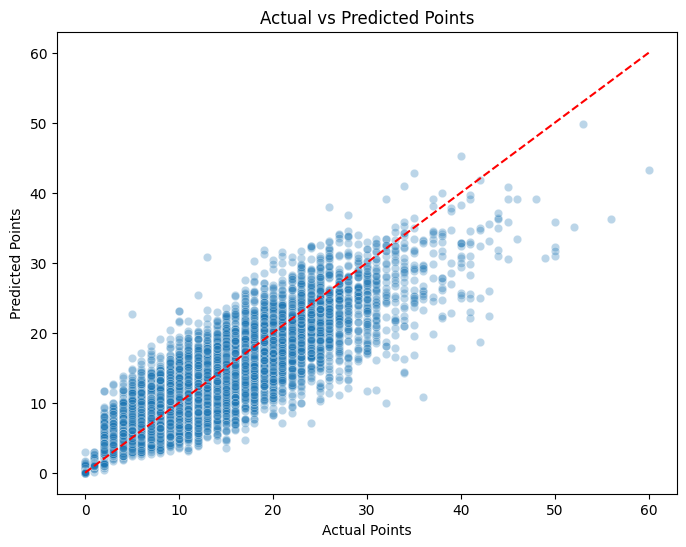

In [10]:

import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,6))
sns.scatterplot(x=test["PTS"], y=test["Lambda"], alpha=0.3)
plt.plot([0, 60], [0, 60], 'r--')  # Perfect prediction line
plt.xlabel("Actual Points")
plt.ylabel("Predicted Points")
plt.title("Actual vs Predicted Points")
plt.show()

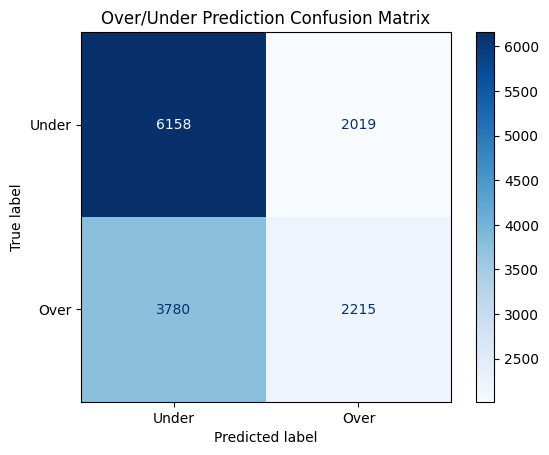

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(test["Actual_Over"], test["Pred_Over"])

disp = ConfusionMatrixDisplay(cm, display_labels=["Under", "Over"])
disp.plot(cmap="Blues")
plt.title("Over/Under Prediction Confusion Matrix")
plt.show()

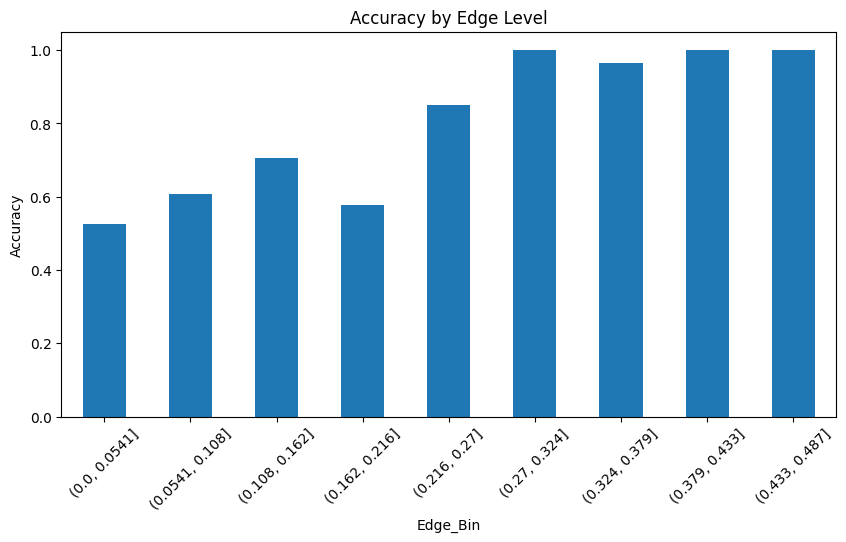

In [12]:
bins = np.linspace(0, test["Edge"].max(), 10)
test["Edge_Bin"] = pd.cut(test["Edge"], bins)

edge_acc = test.groupby("Edge_Bin").apply(
    lambda x: (x["Actual_Over"] == x["Pred_Over"]).mean()
)

edge_acc.plot(kind="bar", figsize=(10,5))
plt.ylabel("Accuracy")
plt.title("Accuracy by Edge Level")
plt.xticks(rotation=45)
plt.show()

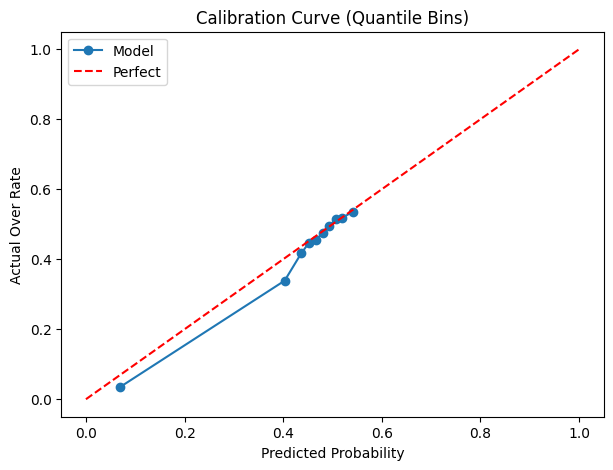

                               Predicted    Actual  Count
Prob_Bin                                                 
(0.012299999999999998, 0.345]   0.068097  0.033850   1418
(0.345, 0.426]                  0.402939  0.338744   1417
(0.426, 0.445]                  0.436343  0.416373   1417
(0.445, 0.459]                  0.452459  0.447424   1417
(0.459, 0.473]                  0.466161  0.454481   1417
(0.473, 0.486]                  0.479693  0.475653   1417
(0.486, 0.5]                    0.493107  0.496119   1417
(0.5, 0.513]                    0.506570  0.513761   1417
(0.513, 0.527]                  0.520163  0.518701   1417
(0.527, 0.632]                  0.540607  0.535261   1418


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create quantile bins (equal number of samples)
test["Prob_Bin"] = pd.qcut(test["Prob_Over"], 10, duplicates='drop')

calibration = test.groupby("Prob_Bin").agg(
    Predicted=("Prob_Over", "mean"),
    Actual=("Actual_Over", "mean"),
    Count=("Actual_Over", "size")
)

plt.figure(figsize=(7,5))

plt.plot(calibration["Predicted"],
         calibration["Actual"],
         marker="o",
         label="Model")

plt.plot([0,1],[0,1],'r--', label="Perfect")

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Over Rate")
plt.title("Calibration Curve (Quantile Bins)")
plt.legend()
plt.show()

print(calibration)

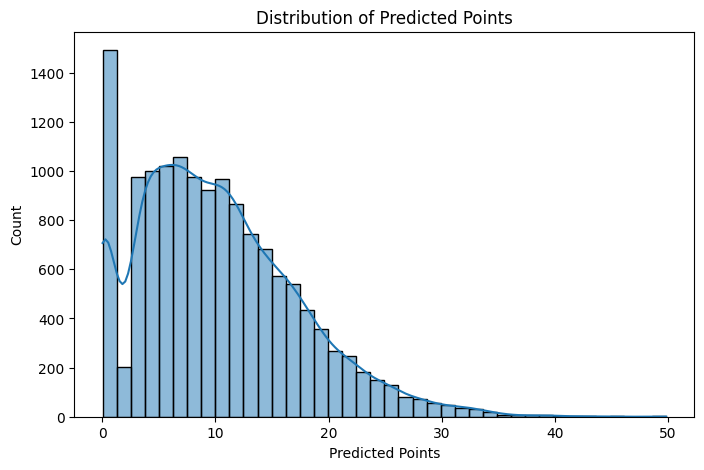

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(test["Lambda"], bins=40, kde=True)
plt.xlabel("Predicted Points")
plt.title("Distribution of Predicted Points")
plt.show()

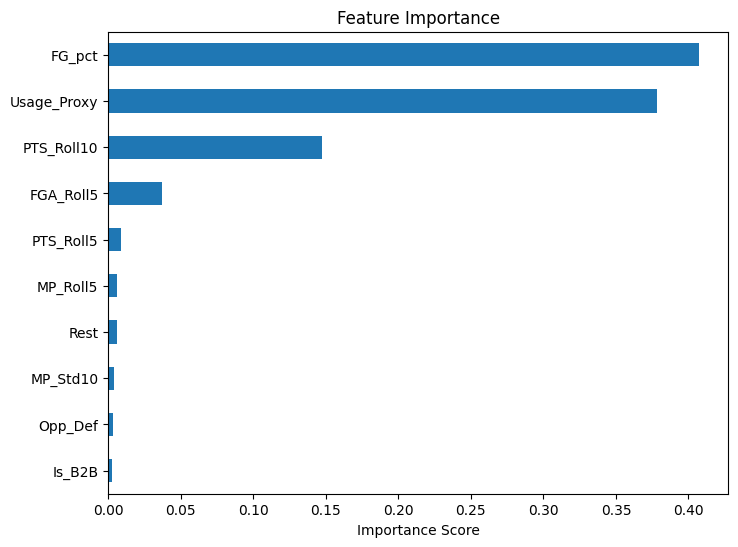

In [15]:
importances = model.feature_importances_

feat_imp = pd.Series(importances, index=FEATURES).sort_values()

feat_imp.plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [16]:
import joblib

joblib.dump(model, "nba_prop_model.pkl")

print("Model saved successfully!")

Model saved successfully!
